# Fraud Detection with Psychology-Inspired Features and Deep Learning

## Problem Definition & Business Context

Fraud detection is a critical challenge for banks and financial institutions. Each year, billions of dollars are lost to fraudulent transactions, and the cost extends beyond direct financial loss to include regulatory fines, reputational damage, and erosion of customer trust.

However, fraud detection systems must strike a delicate balance:
- **Catching fraud** – block malicious transactions to protect customers and the bank.
- **Avoiding false positives** – legitimate transactions that are incorrectly flagged as fraud cause customer frustration, support costs, and lost revenue.

The IEEE-CIS Fraud Detection dataset provides a realistic, anonymized collection of transaction and identity features, mirroring real-world banking data. It includes:
- Transaction features: amount, time, product type, card information, etc.
- Identity features: device type, browser, operating system, etc. (linked via `TransactionID`)

### The Psychological Angle

Fraudsters exhibit behavioral patterns that differ from legitimate users:
- **Velocity**: Fraudsters often make many small transactions quickly to test stolen cards.
- **Amount deviation**: They may attempt unusually large purchases or many small ones to avoid detection.
- **Timing anomalies**: Transactions at odd hours (e.g., 3 AM) when the cardholder is likely asleep.
- **Device mismatch**: Using a new or unrecognized device for a card.

By engineering features that capture these psychological and behavioral patterns, we can build models that are not only more accurate but also more interpretable – aligning with how fraud analysts think.

### Project Goal

1. Build a **baseline logistic regression** model using only basic features.
2. Enhance it with **psychology-inspired features** to quantify their value.
3. Develop a **deep neural network** that leverages all features to outperform the baselines.
4. Demonstrate that understanding human behavior (both of customers and fraudsters) leads to better fraud detection – a key insight for banking cybersecurity.

We will evaluate models using:
- **AUC-ROC** (overall discrimination)
- **Precision-Recall AUC** (better for imbalanced data)
- **Precision at 90% recall** (business metric: how many false alarms when catching most fraud)

# Setup:

## Dataset:
https://www.kaggle.com/competitions/ieee-fraud-detection/data

## Mamba Environment:
mamba create -n fraud_detection -c conda-forge python=3.14.3

mabma install ipykernel

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Config
transaction_train = "ieee_fraud_dataset/train_transaction.csv"
identity_train = "ieee_fraud_dataset/train_identity.csv"

# Pandas Config (show all columns, with full length when printing df)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# Set visualization style
sns.set_style('whitegrid')

In [32]:
# Load the data (adjust paths if needed)
print("Loading transaction data...")
trans = pd.read_csv(transaction_train)
print(f"Transaction shape: {trans.shape}")

print("Loading identity data...")
iden = pd.read_csv(identity_train)
print(f"Identity shape: {iden.shape}")

# Merge on TransactionID (Left Join)
df = trans.merge(iden, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")

# Display first few rows
df.head(5)

Loading transaction data...
Transaction shape: (590540, 394)
Loading identity data...
Identity shape: (144233, 41)
Merged shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 2.5 GB

Fraud rate: 0.0350 (3.50%)
Counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64


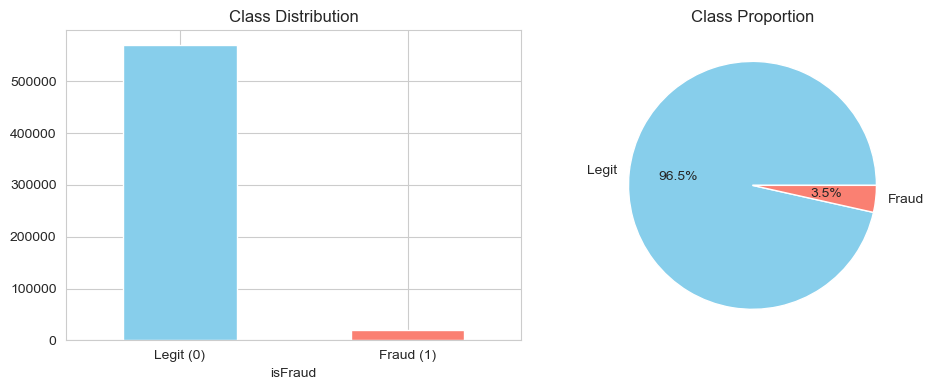

In [33]:
# Check basic info
df.info(verbose=False, memory_usage='deep')

# Check target distribution
fraud_rate = df['isFraud'].mean()
print(f"\nFraud rate: {fraud_rate:.4f} ({fraud_rate*100:.2f}%)")
print(f"Counts:\n{df['isFraud'].value_counts()}")

# Plot target distribution
fig, ax = plt.subplots(1, 2, figsize=(10,4))
df['isFraud'].value_counts().plot(kind='bar', ax=ax[0], color=['skyblue','salmon'])
ax[0].set_title('Class Distribution')
ax[0].set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)

df['isFraud'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                                                colors=['skyblue','salmon'], labels=['Legit','Fraud'])
ax[1].set_title('Class Proportion')
plt.tight_layout()
plt.show()

Columns with missing values: 414

Top 20 columns with highest missing %:
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_23    99.124699
id_22    99.124699
id_27    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_10    87.312290
dtype: float64


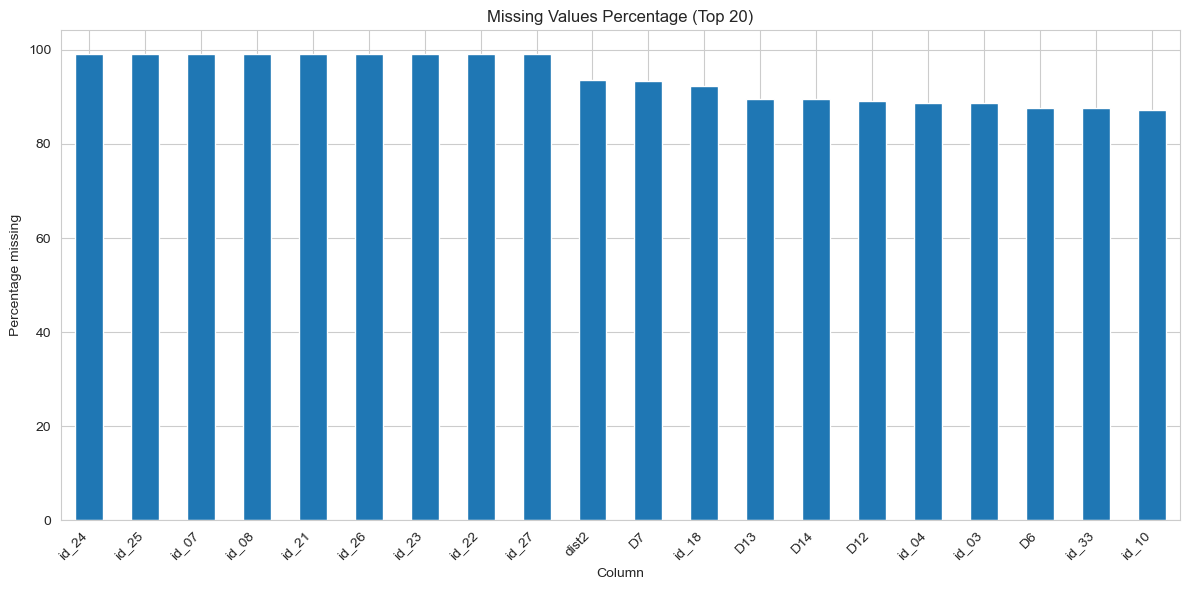

In [34]:
# Calculate missing percentage per column
missing = (df.isnull().sum() / len(df)) * 100
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Columns with missing values: {len(missing)}")
print("\nTop 20 columns with highest missing %:")
print(missing.head(20))

# Plot missing values (top 20)
plt.figure(figsize=(12,6))
missing.head(20).plot(kind='bar')
plt.title('Missing Values Percentage (Top 20)')
plt.ylabel('Percentage missing')
plt.xlabel('Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_175557/2367504207.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Legit', 'Fraud'])


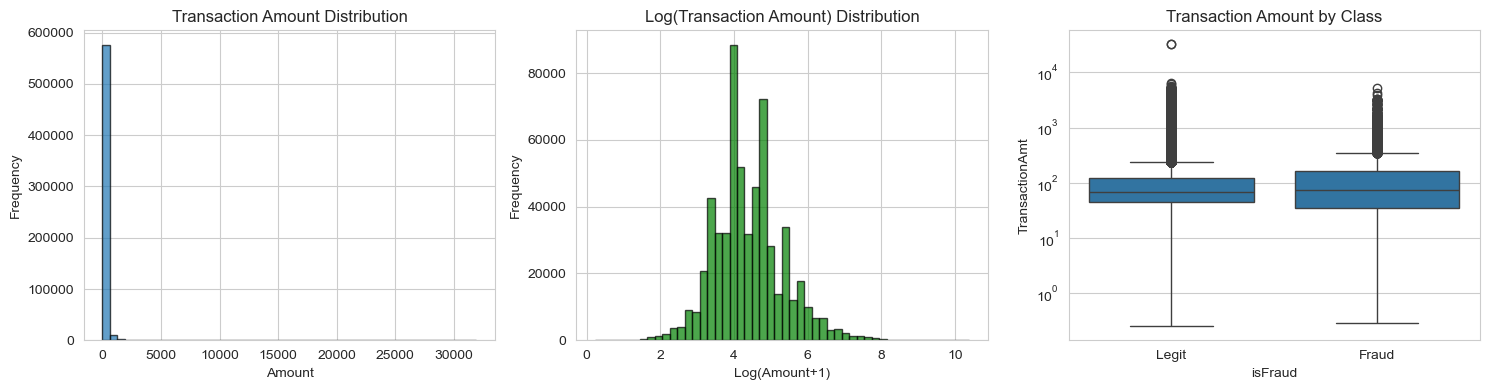

Summary of log transaction amount:
count    590540.000000
mean          4.382960
std           0.937183
min           0.223943
25%           3.791459
50%           4.245190
75%           4.836282
max          10.371564
Name: TransactionAmt, dtype: float64
Summary of fraud classification:
            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


In [39]:
# Distribution of TransactionAmt
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Raw amount
axes[0].hist(df['TransactionAmt'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Log-transformed amount
log_amt = np.log1p(df['TransactionAmt'].dropna())
axes[1].hist(log_amt, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Log(Transaction Amount) Distribution')
axes[1].set_xlabel('Log(Amount+1)')
axes[1].set_ylabel('Frequency')

# Boxplot by fraud class
df_box = df[['TransactionAmt', 'isFraud']].dropna()
sns.boxplot(x='isFraud', y='TransactionAmt', data=df_box, ax=axes[2])
axes[2].set_title('Transaction Amount by Class')
axes[2].set_xticklabels(['Legit', 'Fraud'])
axes[2].set_yscale('log')  # log scale to see outliers

plt.tight_layout()
plt.show()

# Summary statistics by amount
print(f"Summary of log transaction amount:\n{log_amt.describe()}")

# Summary statistics by class
print(f"Summary of fraud classification:\n{df.groupby('isFraud')['TransactionAmt'].describe()}")

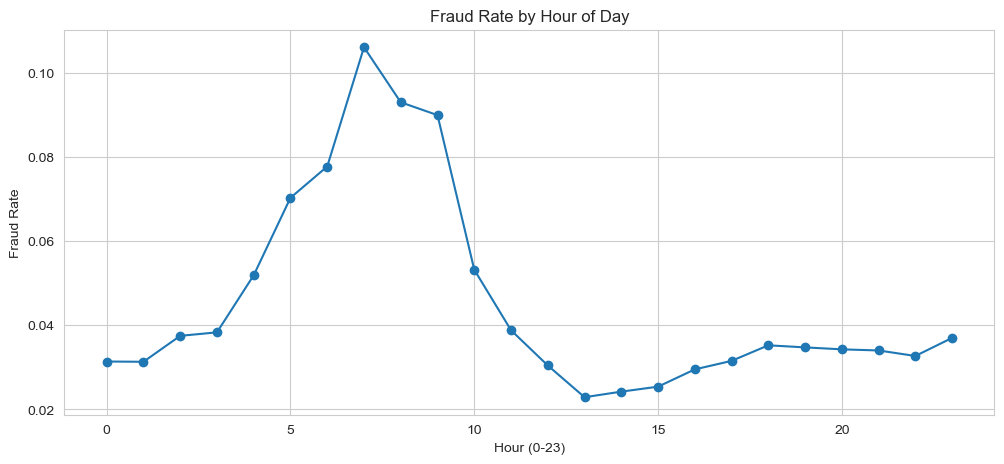

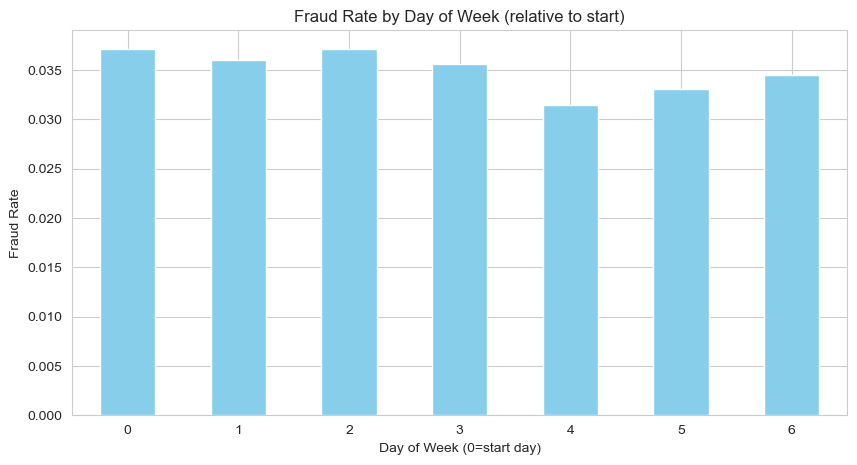

Fraud rate on weekdays: 0.0355
Fraud rate on weekends: 0.0338


In [37]:
# Defragment the DataFrame to avoid performance warnings
df = df.copy()

# Extract time-based features from TransactionDT (seconds)
df = df.assign(
    hour = (df['TransactionDT'] // 3600) % 24,
    day_of_week = (df['TransactionDT'] // 86400) % 7,  # 0-6 relative to start
    day = (df['TransactionDT'] // 86400),  # absolute day number since start
    weekend = lambda x: (x['day_of_week'] >= 5).astype(int)  # Saturday=5, Sunday=6
)

# Plot fraud rate by hour
hourly_fraud = df.groupby('hour')['isFraud'].mean()
plt.figure(figsize=(12,5))
hourly_fraud.plot(kind='line', marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate')
plt.grid(True)
plt.show()

# Fraud rate by day of week
dow_fraud = df.groupby('day_of_week')['isFraud'].mean()
plt.figure(figsize=(10,5))
dow_fraud.plot(kind='bar', color='skyblue')
plt.title('Fraud Rate by Day of Week (relative to start)')
plt.xlabel('Day of Week (0=start day)')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=0)
plt.show()

# Weekend vs weekday fraud rate
weekend_fraud = df.groupby('weekend')['isFraud'].mean()
print(f"Fraud rate on weekdays: {weekend_fraud[0]:.4f}")
print(f"Fraud rate on weekends: {weekend_fraud[1]:.4f}")

## Data Exploration Summary

### 1. Class Imbalance
- **Fraud rate**: 3.5% (20,663 fraud vs. 569,877 legitimate transactions).  
  This severe imbalance confirms that accuracy is not a suitable metric. We'll rely on **AUC-PR**, **precision@recall**, and other ranking metrics.

### 2. Missing Data
- **414 columns** have missing values – many identity fields (e.g., `id_24`–`id_27`) are missing in >99% of rows.  
  - This sparsity suggests that **identity data is only available for a subset of transactions** (likely when additional verification was triggered).  
  - We can create **missingness indicators** (e.g., `id_24_missing`) as features – the very fact that identity data is missing might be predictive.  
  - For columns with moderate missingness (e.g., `dist2`, `D7`, `D12`), we may impute with median or – even better – use models that handle missing values natively (e.g., LightGBM).

### 3. Transaction Amount
- Raw amounts are highly **right-skewed** (mean $134.5, median $68.5).  
- **Log‑transformed amount** distribution is roughly symmetric, centered at ~4.3 (≈ $74). This transformation will be used in modeling.  
- Fraudulent transactions have a **higher median amount** ($75 vs. $68.5) and a **lower maximum** ($5,191 vs. $31,937).  
  - This could indicate that fraudsters avoid extremely high amounts to evade detection, or that stolen cards are often used for moderate purchases.  
  - **Amount alone is not a strong separator**; we need to combine it with behavioral context (e.g., deviation from a card's history).

### 4. Temporal Patterns
- **Hour of day**: Fraud rate peaks between **5–10 AM**, with a maximum around 7 AM, then declines through the evening.  
  - Possible interpretation: fraudsters may operate early in the morning when cardholders are less likely to notice unauthorized transactions, or when automated systems run.  
- **Day of week**: Fraud rate is slightly higher on weekdays (3.55%) than weekends (3.38%).  
  - The bar chart shows variation, but the absolute differences are small. This may reflect legitimate transaction volumes, but we'll still include `weekend` and `day_of_week` as features.  
- **Weekend flag**: Already created, confirms a small difference.

### 5. Key Takeaways for Feature Engineering
- **Velocity features** will capture burst patterns (e.g., many transactions in a short time).  
- **Amount deviation** from a card’s historical average can highlight anomalous purchases.  
- **Time‑of‑day anomalies** (e.g., transactions at unusual hours for a given card) may be flagged using historical activity patterns.  
- **Missingness indicators** from identity data can be powerful – if identity info is missing, the transaction may be riskier.  
- The **V‑engineered features** (e.g., `V1`‑`V339`) already incorporate counts and rankings; we'll let the model leverage them directly.  

These findings will be the foundation of the psychology‑inspired features.

In [53]:
# =============================================================================
# PHASE 2: DATA PREPROCESSING AND BASIC FEATURE ENGINEERING
# =============================================================================

# -----------------------------------------------------------------------------
# Separate features by type
# -----------------------------------------------------------------------------

target = 'isFraud'
id_col = 'TransactionID'

# Start with dtypes
num_dtype_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
obj_dtype_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Known categorical integer columns
categorical_int_cols = [
    'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2',
    'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20',
    'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29',
    'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
    'DeviceType', 'DeviceInfo'
]
categorical_int_cols = [col for col in categorical_int_cols if col in df.columns]

# Combine: categorical = object‑dtype columns + designated integer columns
categorical_cols = list(set(obj_dtype_cols + categorical_int_cols))

# Numeric = all numeric columns that are NOT in categorical and NOT target/id
numeric_cols = [col for col in num_dtype_cols if col not in categorical_cols + [target, id_col]]

print("Feature type separation (no overlap):")
print(f"  Numeric columns: {len(numeric_cols)}")
print(f"  Categorical columns: {len(categorical_cols)}")
print(f"  Total feature columns: {len(numeric_cols) + len(categorical_cols)}")

# -----------------------------------------------------------------------------
# Stratified train/validation split (before any imputation/encoding)
# -----------------------------------------------------------------------------

X = df.drop(columns=[target, id_col])
y = df[target]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nData split:")
print(f"  Train shape: {X_train.shape}")
print(f"  Validation shape: {X_valid.shape}")
print(f"  Train fraud rate: {y_train.mean():.4f}")
print(f"  Validation fraud rate: {y_valid.mean():.4f}")

# -----------------------------------------------------------------------------
# Handle Missing Values (Post‑Split)
# -----------------------------------------------------------------------------

# Copy X_train and X_valid to avoid modifying original dataframes
X_train_processed = X_train.copy()
X_valid_processed = X_valid.copy()

# Create missing‑value indicators for columns with missing data in training
missing_cols_train = [col for col in X_train.columns if X_train[col].isna().any()]
print(f"Adding missing indicators for {len(missing_cols_train)} columns...")

# Build a dictionary of indicator Series for train and validation
train_indicators = {}
valid_indicators = {}
for col in missing_cols_train:
    indicator_name = f"{col}_missing"
    train_indicators[indicator_name] = X_train[col].isna().astype(int)
    valid_indicators[indicator_name] = X_valid[col].isna().astype(int)

# Concatenate all indicators at once to avoid fragmentation
train_indicators_df = pd.concat(train_indicators, axis=1)
valid_indicators_df = pd.concat(valid_indicators, axis=1)

# Join them to the processed DataFrames
X_train_processed = pd.concat([X_train_processed, train_indicators_df], axis=1)
X_valid_processed = pd.concat([X_valid_processed, valid_indicators_df], axis=1)

print(f"Added missing indicators for {len(missing_cols_train)} columns.")

# Impute missing values using training statistics
# Numeric columns: median
for col in numeric_cols:
    if col in X_train_processed.columns:
        median_val = X_train[col].median()
        # Assign back the filled Series – this respects CoW
        X_train_processed[col] = X_train_processed[col].fillna(median_val)
        X_valid_processed[col] = X_valid_processed[col].fillna(median_val)

# Categorical columns: mode (most frequent)
for col in categorical_cols:
    if col in X_train_processed.columns:
        mode_vals = X_train[col].mode(dropna=True)
        mode_val = mode_vals.iloc[0] if len(mode_vals) > 0 else "MISSING"
        X_train_processed[col] = X_train_processed[col].fillna(mode_val)
        X_valid_processed[col] = X_valid_processed[col].fillna(mode_val)

print("Missing value imputation complete.")

Feature type separation (no overlap):
  Numeric columns: 387
  Categorical columns: 49
  Total feature columns: 436

Data split:
  Train shape: (472432, 436)
  Validation shape: (118108, 436)
  Train fraud rate: 0.0350
  Validation fraud rate: 0.0350
Adding missing indicators for 414 columns...
Added missing indicators for 414 columns.
Missing value imputation complete.


In [54]:
# -----------------------------------------------------------------------------
# Sanity Checks for Processed Data
# -----------------------------------------------------------------------------

print("Train shape:", X_train_processed.shape)
print("Validation shape:", X_valid_processed.shape)

print("\nMissing values in train:", X_train_processed.isna().sum().sum())
print("Missing values in validation:", X_valid_processed.isna().sum().sum())

# Count missing indicator columns
indicator_cols = [col for col in X_train_processed.columns if col.endswith('_missing')]
print(f"\nNumber of missing indicator columns: {len(indicator_cols)}")
print("Sample indicators:", indicator_cols[:5])

# Verify that original columns no longer have missing values
original_numeric_with_missing = [col for col in numeric_cols if col in X_train.columns and X_train[col].isna().any()]
if original_numeric_with_missing:
    print(f"\nNumeric columns that originally had missing values (sample): {original_numeric_with_missing[:5]}")
    for col in original_numeric_with_missing[:5]:
        print(f"  {col}: train missing after imputation: {X_train_processed[col].isna().sum()}")

original_cat_with_missing = [col for col in categorical_cols if col in X_train.columns and X_train[col].isna().any()]
if original_cat_with_missing:
    print(f"\nCategorical columns that originally had missing values (sample): {original_cat_with_missing[:5]}")
    for col in original_cat_with_missing[:5]:
        print(f"  {col}: train missing after imputation: {X_train_processed[col].isna().sum()}")

# Check data types of new indicators
print("\nData types of first few indicator columns:")
print(X_train_processed[indicator_cols[:5]].dtypes)

Train shape: (472432, 850)
Validation shape: (118108, 850)

Missing values in train: 0
Missing values in validation: 0

Number of missing indicator columns: 414
Sample indicators: ['card2_missing', 'card3_missing', 'card4_missing', 'card5_missing', 'card6_missing']

Numeric columns that originally had missing values (sample): ['dist1', 'dist2', 'D1', 'D2', 'D3']
  dist1: train missing after imputation: 0
  dist2: train missing after imputation: 0
  D1: train missing after imputation: 0
  D2: train missing after imputation: 0
  D3: train missing after imputation: 0

Categorical columns that originally had missing values (sample): ['id_12', 'addr1', 'card4', 'addr2', 'id_19']
  id_12: train missing after imputation: 0
  addr1: train missing after imputation: 0
  card4: train missing after imputation: 0
  addr2: train missing after imputation: 0
  id_19: train missing after imputation: 0

Data types of first few indicator columns:
card2_missing    int64
card3_missing    int64
card4_missin

In [ ]:
# -----------------------------------------------------------------------------
# Encode Categorical Variables
# -----------------------------------------------------------------------------

# Keep non‑categorical columns (numeric + missing indicators)
non_cat_cols = [col for col in X_train_processed.columns if col not in categorical_cols]
X_train_base = X_train_processed[non_cat_cols].copy()
X_valid_base = X_valid_processed[non_cat_cols].copy()

encoded_train_dfs = [X_train_base]
encoded_valid_dfs = [X_valid_base]

for col in categorical_cols:
    if col not in X_train_processed.columns:
        continue  # skip if column somehow missing

    n_unique = X_train_processed[col].nunique()
    print(f"Encoding '{col}' ({n_unique} unique values)...")

    # --- One‑hot encoding for low cardinality ---
    if n_unique <= 10:
        # Get dummies on training, drop first category to avoid dummy trap
        dummies_train = pd.get_dummies(
            X_train_processed[col],
            prefix=col,
            drop_first=True,
            dtype=int
        )
        # Get dummies on validation, then align columns to training
        dummies_valid = pd.get_dummies(
            X_valid_processed[col],
            prefix=col,
            drop_first=True,
            dtype=int
        )
        # Ensure validation has same columns as training (fill missing with 0)
        dummies_valid = dummies_valid.reindex(columns=dummies_train.columns, fill_value=0)

        encoded_train_dfs.append(dummies_train)
        encoded_valid_dfs.append(dummies_valid)

    # --- Frequency encoding for high cardinality ---
    else:
        # Compute frequency map from training (raw counts)
        freq_map = X_train_processed[col].value_counts().to_dict()

        # Apply map, fill unseen categories with 0
        freq_train = X_train_processed[col].map(freq_map).fillna(0).astype(int)
        freq_valid = X_valid_processed[col].map(freq_map).fillna(0).astype(int)

        # Convert to DataFrame with a clear name
        freq_train_df = freq_train.to_frame(name=f"{col}_freq")
        freq_valid_df = freq_valid.to_frame(name=f"{col}_freq")

        encoded_train_dfs.append(freq_train_df)
        encoded_valid_dfs.append(freq_valid_df)

# Concatenate all parts
X_train_encoded = pd.concat(encoded_train_dfs, axis=1)
X_valid_encoded = pd.concat(encoded_valid_dfs, axis=1)

print("\nEncoding complete.")
print(f"Final train shape: {X_train_encoded.shape}")
print(f"Final validation shape: {X_valid_encoded.shape}")

# Check if any original categorical columns remain
remaining_cats = [col for col in categorical_cols if col in X_train_encoded.columns]
print(f"Original categorical columns still present: {remaining_cats}")

# Show first few columns of the encoded data
print("\nColumns of encoded train set:")
print(X_train_encoded.columns.tolist())

Encoding 'id_12' (2 unique values)...
Encoding 'addr1' (304 unique values)...
Encoding 'card4' (4 unique values)...
Encoding 'addr2' (69 unique values)...
Encoding 'id_19' (517 unique values)...
Encoding 'M4' (3 unique values)...
Encoding 'ProductCD' (5 unique values)...
Encoding 'id_29' (2 unique values)...
Encoding 'id_15' (3 unique values)...
Encoding 'M1' (2 unique values)...
Encoding 'M3' (2 unique values)...
Encoding 'M8' (2 unique values)...
Encoding 'id_31' (124 unique values)...
Encoding 'id_35' (2 unique values)...
Encoding 'id_38' (2 unique values)...
Encoding 'id_22' (24 unique values)...
Encoding 'M7' (2 unique values)...
Encoding 'id_30' (75 unique values)...
Encoding 'id_20' (383 unique values)...
Encoding 'M6' (2 unique values)...
Encoding 'DeviceType' (2 unique values)...
Encoding 'id_26' (91 unique values)...
Encoding 'DeviceInfo' (1686 unique values)...
Encoding 'id_25' (323 unique values)...
Encoding 'id_36' (2 unique values)...
Encoding 'id_17' (101 unique values).